# Problem - Logistic Regression with Stable BCE

## Interview question

Implement binary logistic regression from scratch. Given `X: [N, D]` and labels `y: [N]` in `{0,1}`, train a classifier using gradient descent.

## What is being asked

You need to implement logits, sigmoid probabilities, binary cross-entropy, and the gradient update. The important part is numerical stability.

## Clarifying questions

- Are labels binary or multi-class?
- Should I return probabilities or class labels?
- Should I use regularization?
- Is this NumPy or PyTorch?

## Solution

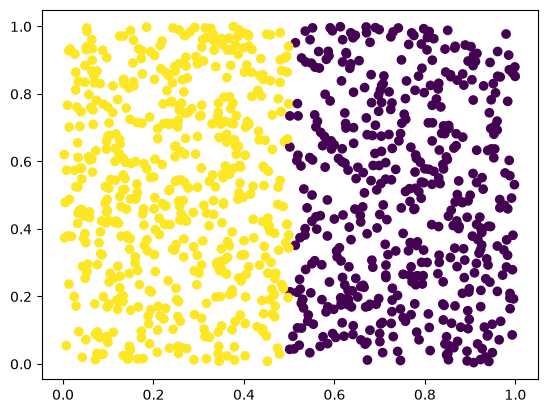

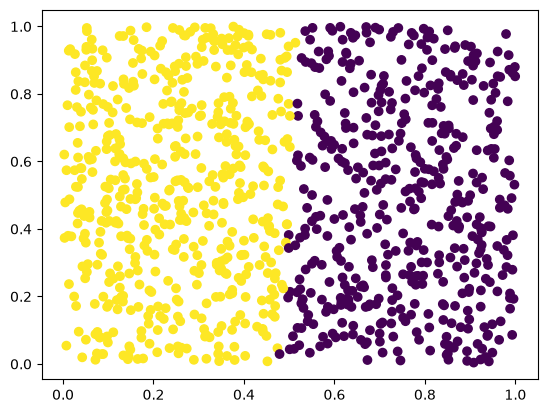

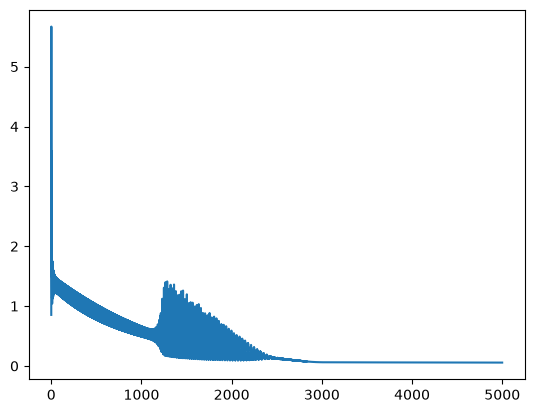

In [ ]:
import numpy as np
import torch as th
from typing import Tuple, List
import matplotlib.pyplot as plt
"""

Input: X (N x D), Y (N x 1) 
Output: W (D x 1), b (1)

Z = X @ W + b (logit N x 1)
Y' = sigmoid(Z) (in range [0, 1])

sigmoid(x) = 1/(1+exp(-x))

L = BCE (Y, Y') =  - Y * log(Y') - (1-Y) * log(1-Y')

d_sigmoid(x) = sigmoid(x)(1-sigmoid(x))

dL/dw = dL/dY' * dY'/dZ * dZ*dw 
dL/dY' = -Y/Y' + (1-Y)/(1-Y') = (-Y + YY' -Y' - YY')/(Y' * (1-Y')) = (Y' - Y)/(Y' * (1-Y'))
dY'/dz = Y'(1-Y') (cancels with above)
dZ/dw = X

dL/dw = X.T @ (Y' - Y)

dL/db = dL/dY' * dY'/dZ * dZ*db 
dL/dY' = -Y/Y' + (1-Y)/(1-Y') = (-Y + YY' -Y' - YY')/(Y' * (1-Y')) = (Y' - Y)/(Y' * (1-Y'))
dY'/dz = Y'(1-Y') (cancels with above)
dZ/db = 1

dL/db = Y' - Y

"""

def sigmoid(Z: np.ndarray) -> np.ndarray:
    Z = np.clip(Z, -50, 50)
    return 1/(1+np.exp(-Z))

def logistic_regression_fit(X: np.ndarray, Y: np.ndarray, lr: float = 0.1, steps: int = 5000) -> Tuple[np.ndarray, np.ndarray, List[float]]:
    N, D = X.shape[0], X.shape[1]
    W = np.random.rand(D, 1)
    b = np.random.rand()

    losses = []
    for _ in range(steps):
        Z = X @ W + b # logits
        Y_p = sigmoid(Z)

        loss = np.mean(- Y * np.log(Y_p) - (1-Y) * np.log(1-Y_p))
        losses.append(loss)

        g_w = X.T @ (Y_p - Y)
        g_b = (Y_p - Y).mean()

        W -= lr*g_w
        b -= lr*g_b

    return W, b, losses


def pred(W, b, X, threshold=0.5):
    return (sigmoid(X @ W + b) > 0.5).astype(np.int32)

if __name__ == "__main__":
    N = 1000
    D = 2
    X = np.random.rand(N, D)
    # Y = (X[:, 1]**2 + X[:, 0]**2<0.5).astype(np.int32)
    Y = (X[:, 0]<0.5).astype(np.int32)

    plt.scatter(X[:, 0], X[:, 1], c=Y)
    plt.show()
    
    W, b, losses = logistic_regression_fit(X, Y[..., None])

    Y_p = pred(W, b, X)

    plt.scatter(X[:, 0], X[:, 1], c=Y_p)
    plt.show()

    plt.plot(np.arange(len(losses)), losses)
    plt.show()

